### Asian Hornet

In [7]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [67]:
df = pd.read_csv('Data/Vespa velutina.csv')
df.head(10)

C:\Users\bjh\AppData\Local\Temp\ipykernel_14980\915384658.py:1: DtypeWarning: Columns (0: Vespa velutina) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Data/Vespa velutina.csv')


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Vespa velutina
0,50.75,5.65,2010-01-01,0.0,0,0
1,50.75,5.65,2010-01-02,26.0,0,0
2,50.75,5.65,2010-01-03,3.0,0,0
3,50.75,5.65,2010-01-04,0.0,0,0
4,50.75,5.65,2010-01-05,0.0,0,0
5,50.75,5.65,2010-01-06,1.0,0,0
6,50.75,5.65,2010-01-07,0.0,0,0
7,50.75,5.65,2010-01-08,1.0,0,0
8,50.75,5.65,2010-01-09,0.0,0,0
9,50.75,5.65,2010-01-10,0.0,0,0


---

## 1. Business Understanding

#### **Situation Description**

The Vespa Velutina otherwise known as the Asian Hornet is an invasive species of insect present in the Netherlands. The Data Science Research Group tracks appearances of multiple plants and animals, including the Vespa, through the reports of various volunteers. The research group wants a way to predict the appearances of future Vespa. 

#### **Business Objective(s)**

The goal of this notebook is to create a model that can accurately predict whether or not a Vespa will be located within an area on a specific date.
This model is meant to give insight into the behavior of the Vespa, which can be used for the potential combating of the invasive Vespa.

#### **Data Mining Goal(s)**

The goal is to create a new binary column `Vespa_spotted` that indicated whether a Vespa has been spotted on a specific place and date.

While we are creating a new column, this is a supervised learning modeling task. We are trying to make predictions using existing and labeled data columns. We already know what we are trying to make, a prediction model to show if a Vespa will be spotted at a specific place and time.

This is a classification task. While we are using the `Vespa Velutina` column which shows the amount of Vespa spotted using numbers to create our model, the ultimate goal is simply to predict if there will be sighting, not how many will be sighted.

#### **Success Criteria**

With the large amount of zero values within our data set, simply predicting no Vespa will be spotted would result in a high score with most metrics. This would not be a useful result however, and the accurate prediction of when Vespa will be spotted is more valuable, therefore, to measure the success of our model we will mostly look towards the recall score.

**Recall:** 80%

In case the above percentage proves to be able to be achieved too easily, the possibility to pick a more strict goal will remain.

---

## 2. Data Understanding

**Data exploration**

In [24]:
df = df.iloc[:-30]

print(df)
df['eventDate'] = pd.to_datetime(df['eventDate'])
df['year'] = df['eventDate'].dt.year
df['month'] = df['eventDate'].dt.month

print(f"Dataset vorm: {df.shape}")
print(f"\nEerste rijen:")
print(df.head())
print(f"\nGegevenstypen:")
print(df.dtypes)
print(f"\nBasisstatistieken:")
print(df.describe())

          decimalLatitude  decimalLongitude   eventDate  total_observations  \
0                   50.75              5.65  2010-01-01                 0.0   
1                   50.75              5.65  2010-01-02                26.0   
2                   50.75              5.65  2010-01-03                 3.0   
3                   50.75              5.65  2010-01-04                 0.0   
4                   50.75              5.65  2010-01-05                 0.0   
...                   ...               ...         ...                 ...   
12558751            53.50              6.55  2025-12-27                 0.0   
12558752            53.50              6.55  2025-12-28                 0.0   
12558753            53.50              6.55  2025-12-29                 0.0   
12558754            53.50              6.55  2025-12-30                 0.0   
12558755            53.50              6.55  2025-12-31                 0.0   

          speciesgroup_observations Vespa velutina 

**Visualizations and patterns**

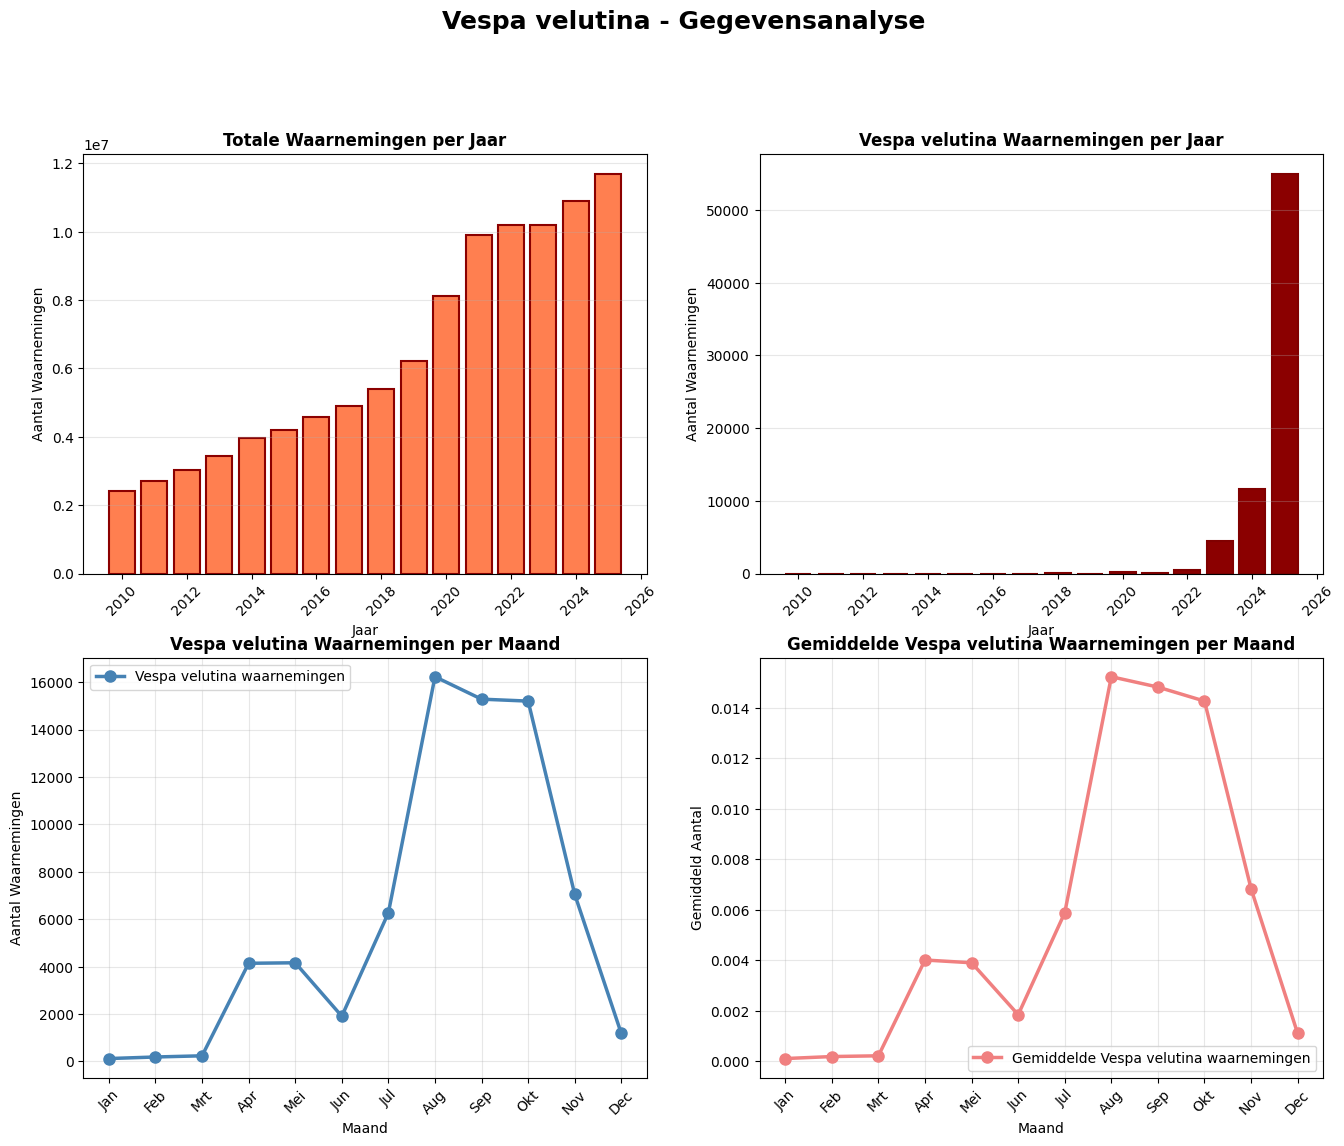

In [25]:


# Maak een figure met meerdere subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Vespa velutina - Gegevensanalyse', fontsize=18, fontweight='bold', y=1.00)

# 1. Totale waarnemingen per jaar
yearly_data = df.groupby('year')['total_observations'].sum()
axes[0, 0].bar(yearly_data.index, yearly_data.values, color='coral', edgecolor='darkred', linewidth=1.5)
axes[0, 0].set_title('Totale Waarnemingen per Jaar', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Jaar')
axes[0, 0].set_ylabel('Aantal Waarnemingen')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Vespa velutina waarnemingen per jaar
vespa_yearly = pd.to_numeric(df['Vespa velutina'], errors='coerce').fillna(0).groupby(df['year']).sum()
axes[0, 1].bar(vespa_yearly.index, vespa_yearly.values, color='darkred', edgecolor='maroon', linewidth=1.5)
axes[0, 1].set_title('Vespa velutina Waarnemingen per Jaar', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Jaar')
axes[0, 1].set_ylabel('Aantal Waarnemingen')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Vespa velutina waarnemingen per maand
vespa_monthly = pd.to_numeric(df['Vespa velutina'], errors='coerce').fillna(0).groupby(df['month']).sum()
month_names = ['Jan', 'Feb', 'Mrt', 'Apr', 'Mei', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec']
axes[1, 0].plot(vespa_monthly.index, vespa_monthly.values, marker='o', linewidth=2.5, markersize=8, 
                color='steelblue', label='Vespa velutina waarnemingen')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names, rotation=45)
axes[1, 0].set_title('Vespa velutina Waarnemingen per Maand', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Maand')
axes[1, 0].set_ylabel('Aantal Waarnemingen')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# 4. gemiddelde Vespa velutina waarnemingen per maand 
vespa_monthly_avg = pd.to_numeric(df['Vespa velutina'], errors='coerce').fillna(0).groupby(df['month']).mean()
axes[1, 1].plot(vespa_monthly_avg.index, vespa_monthly_avg.values, marker='o', linewidth=2.5, markersize=8,
                color='lightcoral', label='Gemiddelde Vespa velutina waarnemingen')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(month_names, rotation=45)
axes[1, 1].set_title('Gemiddelde Vespa velutina Waarnemingen per Maand', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Maand')
axes[1, 1].set_ylabel('Gemiddeld Aantal')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

## Data Insights and Data Quality

### Data Insights

### Data Quality Issues

---

## 3. Data Preparation

**Cleaning and preprocessing**

our customer had already done some data cleaning so our data set is reletively clean.

the biggest problem in the data set is the mix between strings and integers, these all have to be converted to integers.

there are also some data anomoly's such as 9999 values that make no sense and repeated 1001 value's that also seem incorrect as well.

## Data Cleaning and Preprocessing

In [38]:
df['Vespa velutina'].value_counts()

Vespa velutina
0     12404637
0       106914
1        33020
2         8791
3         2980
4         1239
5          540
6          274
7          151
8           86
9           34
10          30
11          16
12          11
13          10
14           6
15           4
19           3
16           3
20           2
32           1
22           1
17           1
1            1
3            1
Name: count, dtype: int64

In [68]:
# removes unknowns from dataset

# normalize the column first
df["Vespa velutina"] = (
    df["Vespa velutina"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# remove rows with unknown-like values
df = df[
    ~df["Vespa velutina"].str.contains(
        r"^(unknown|\?|na|n/a|nan)?$",
        na=True
    )
]

C:\Users\bjh\AppData\Local\Temp\ipykernel_14980\2791191581.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df["Vespa velutina"].str.contains(


In [69]:
# changes all strings to int
def convert_mixed(val):
    try:
        return int(val)
    except:
        return val

df["Vespa velutina"] = df["Vespa velutina"].apply(convert_mixed)

# encode only the strings
strings = df["Vespa velutina"].astype(str)
df["Vespa velutina"] = pd.factorize(strings)[0]

In [77]:
def RM_incorrect_num(val):
  if val == 1011:
    return pd.NA
  else:
    return val
  
df["speciesgroup_observations"] = df["speciesgroup_observations"].apply(RM_incorrect_num)

df = df.dropna(subset=["speciesgroup_observations"])


In [ ]:
#create a csv to save proceccing time not having to rerun all previous commands
df.to_csv("Data/Vespa velutina Fixed.csv")